<a href="https://colab.research.google.com/github/VedikaGurav03/DeepLearning/blob/colab-branch/DeepLearning_NLP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Practical 02:**  NLP Preprocessing and Text Classification

**Name:** Vedika Gurav

**Prn:** 202301040156

**Batch:** DL1


**Github Link:**




Natural Language Processing (NLP) enables machines to understand human language.

In this practical, we classify movie reviews into positive and negative sentiments.

Example:
"I love this movie" → Positive
"This is bad" → Negative

This notebook demonstrates a complete NLP pipeline for sentiment analysis. It covers data loading, extensive text preprocessing (tokenization, stopword removal, stemming, lemmatization), feature extraction using CountVectorizer and TF-IDF, training and evaluation of various machine learning models (Logistic Regression, Naive Bayes, Decision Tree, Random Forest, KNN, SVM), and building scratch implementations of Naive Bayes and KNN.

In [ ]:
import pandas as pd
import numpy as np
import re
import nltk
import matplotlib.pyplot as plt
import seaborn as sns

from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Download necessary NLTK data
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


True

In [ ]:
# Load the IMDB dataset from a CSV file
data = pd.read_csv("IMDB Dataset.csv")
# Display the first few rows of the DataFrame
data.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


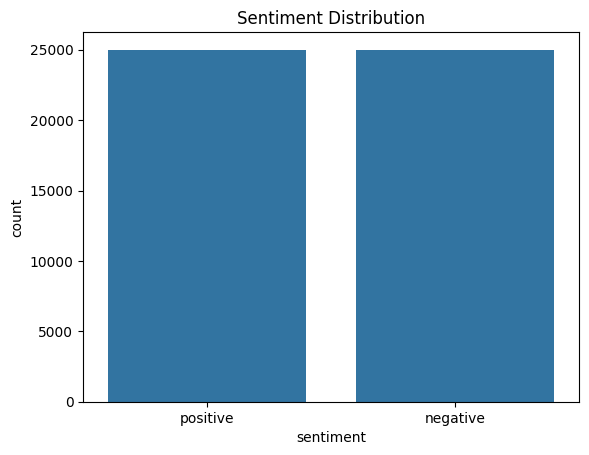

In [ ]:
# Create a count plot to visualize the distribution of sentiment labels
sns.countplot(x=data['sentiment'])
# Set the title of the plot
plt.title("Sentiment Distribution")
# Display the plot
plt.show()

In [ ]:
# Initialize NLTK components for text preprocessing
stop_words = set(stopwords.words('english')) # Set of English stopwords
stemmer = PorterStemmer() # Stemmer for reducing words to their root form
lemmatizer = WordNetLemmatizer() # Lemmatizer for reducing words to their base form

def preprocess(text):
    # Convert text to lowercase
    text = text.lower()
    # Remove non-alphabetic characters
    text = re.sub('[^a-zA-Z]', ' ', text)

    words = text.split()   # Tokenization: Split text into individual words

    # Stopword removal: Remove common words that don't add much meaning
    words = [w for w in words if w not in stop_words]

    # Stemming: Reduce words to their root form (e.g., 'running' -> 'run')
    words = [stemmer.stem(w) for w in words]

    # Lemmatization: Reduce words to their base form (e.g., 'better' -> 'good')
    words = [lemmatizer.lemmatize(w) for w in words]

    # Join the processed words back into a single string
    return " ".join(words)

# Apply the preprocessing function to the 'review' column and store in a new 'cleaned' column
data['cleaned'] = data['review'].apply(preprocess)

# Display the original and cleaned reviews for comparison
data[['review', 'cleaned']].head()

,review,cleaned
0,One of the other reviewers has mentioned that ...,one review mention watch oz episod hook right ...
1,A wonderful little production. <br /><br />The...,wonder littl product br br film techniqu unass...
2,I thought this was a wonderful way to spend ti...,thought wonder way spend time hot summer weeke...
3,Basically there's a family where a little boy ...,basic famili littl boy jake think zombi closet...
4,"Petter Mattei's ""Love in the Time of Money"" is...",petter mattei love time money visual stun film...


In [ ]:
# Label encoding: Convert 'positive' sentiment to 1 and 'negative' to 0
data['sentiment'] = data['sentiment'].map({'positive':1, 'negative':0})

In [ ]:
# Train Test Split: Divide the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    data['cleaned'], data['sentiment'], test_size=0.2, random_state=42 # 80% train, 20% test, fixed random state for reproducibility
)

In [ ]:
# Count Vectorizer: Convert a collection of text documents to a matrix of token counts
from sklearn.feature_extraction.text import CountVectorizer

cv = CountVectorizer(max_features=5000) # Initialize CountVectorizer with a maximum of 5000 features
X_train_cv = cv.fit_transform(X_train) # Fit and transform training data
X_test_cv = cv.transform(X_test) # Transform testing data using the fitted vectorizer

In [ ]:
# TF-IDF Vectorizer: Convert a collection of raw documents to a matrix of TF-IDF features
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000) # Initialize TfidfVectorizer with a maximum of 5000 features
X_train_tfidf = tfidf.fit_transform(X_train) # Fit and transform training data
X_test_tfidf = tfidf.transform(X_test) # Transform testing data using the fitted vectorizer

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

# Define a dictionary of machine learning models to be evaluated
models = {
    "Logistic Regression": LogisticRegression(max_iter=300), # Logistic Regression model
    "Naive Bayes": MultinomialNB(), # Multinomial Naive Bayes model
    "Decision Tree": DecisionTreeClassifier(), # Decision Tree Classifier
    "Random Forest": RandomForestClassifier(), # Random Forest Classifier
    "KNN": KNeighborsClassifier(), # K-Nearest Neighbors Classifier
    "SVM": SVC() # Support Vector Machine Classifier
}


Logistic Regression
Accuracy: 0.8856

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.87      0.88      4961
           1       0.88      0.90      0.89      5039

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



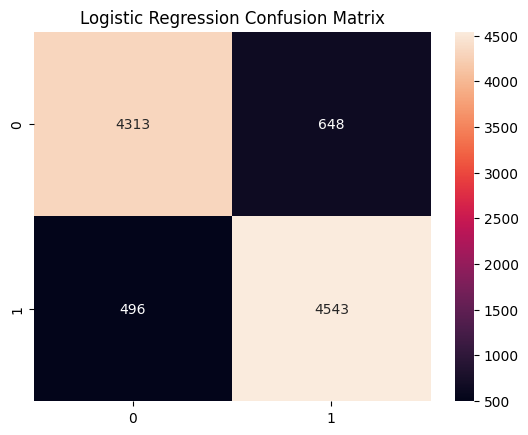


Naive Bayes
Accuracy: 0.8522

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.85      0.85      4961
           1       0.85      0.86      0.85      5039

    accuracy                           0.85     10000
   macro avg       0.85      0.85      0.85     10000
weighted avg       0.85      0.85      0.85     10000



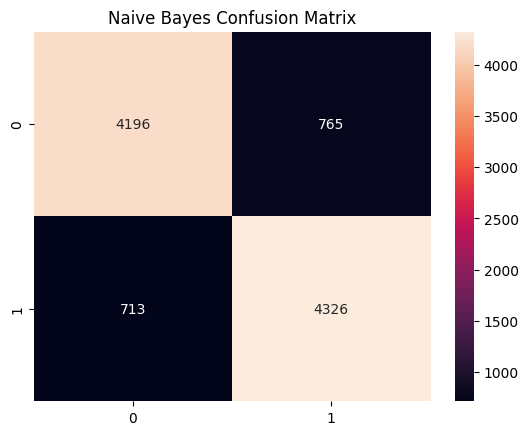


Decision Tree
Accuracy: 0.7161

Classification Report:
              precision    recall  f1-score   support

           0       0.71      0.71      0.71      4961
           1       0.72      0.72      0.72      5039

    accuracy                           0.72     10000
   macro avg       0.72      0.72      0.72     10000
weighted avg       0.72      0.72      0.72     10000



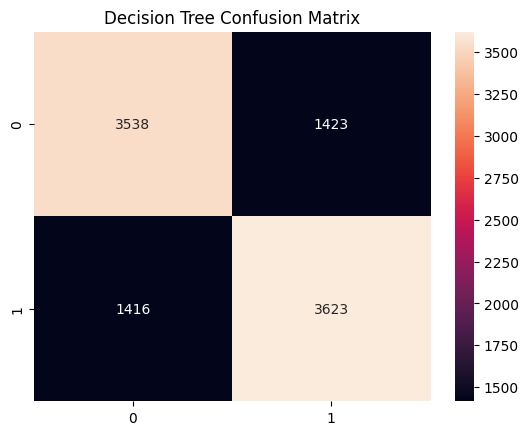


Random Forest
Accuracy: 0.8491

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.86      0.85      4961
           1       0.86      0.84      0.85      5039

    accuracy                           0.85     10000
   macro avg       0.85      0.85      0.85     10000
weighted avg       0.85      0.85      0.85     10000



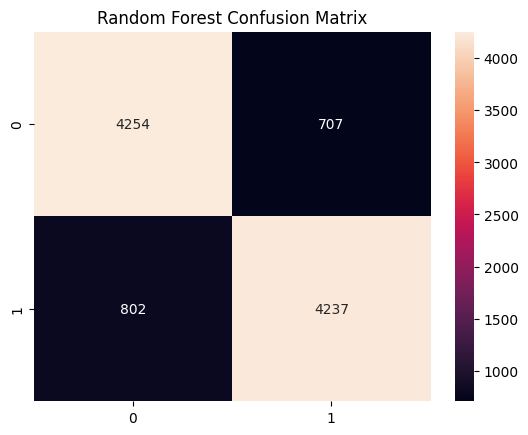


KNN
Accuracy: 0.7524

Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.71      0.74      4961
           1       0.73      0.80      0.76      5039

    accuracy                           0.75     10000
   macro avg       0.75      0.75      0.75     10000
weighted avg       0.75      0.75      0.75     10000



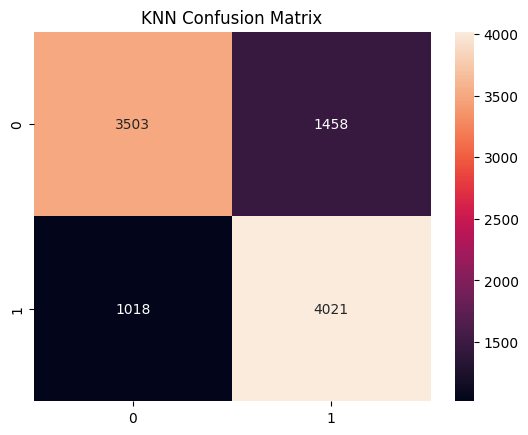

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

results = {}

# Iterate through each model defined in the 'models' dictionary
for name, model in models.items():
    # Train the model using TF-IDF transformed training data
    model.fit(X_train_tfidf, y_train)
    # Make predictions on the TF-IDF transformed test data
    preds = model.predict(X_test_tfidf)

    # Calculate accuracy score
    acc = accuracy_score(y_test, preds)
    # Store the accuracy in the results dictionary
    results[name] = acc

    # Print evaluation metrics for each model
    print("\n==========================")
    print(name)
    print("==========================")

    print("Accuracy:", acc)
    print("\nClassification Report:")
    print(classification_report(y_test, preds))

    # Generate and plot confusion matrix
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d') # Visualize confusion matrix with seaborn
    plt.title(name + " Confusion Matrix") # Set plot title
    plt.show() # Display the plot

In [ ]:
import pandas as pd

# Initialize an empty results dictionary to prevent NameError if previous cell was not executed
results = {}

# Create a DataFrame from the 'results' dictionary to display model accuracies
results_df = pd.DataFrame(list(results.items()), columns=["Model", "Accuracy"])
# Print the DataFrame
print(results_df)

Empty DataFrame
Columns: [Model, Accuracy]
Index: []


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

# Ensure X_train, X_test, y_train, y_test are defined from prior cells.
# If not, please run cells related to train-test split before this one.

# Count Vectorizer: Convert a collection of text documents to a matrix of token counts
cv = CountVectorizer(max_features=5000) # Initialize CountVectorizer with a maximum of 5000 features
X_train_cv = cv.fit_transform(X_train) # Fit and transform training data
X_test_cv = cv.transform(X_test) # Transform testing data using the fitted vectorizer

# TF-IDF Vectorizer: Convert a collection of raw documents to a matrix of TF-IDF features
tfidf = TfidfVectorizer(max_features=5000) # Initialize TfidfVectorizer with a maximum of 5000 features
X_train_tfidf = tfidf.fit_transform(X_train) # Fit and transform training data
X_test_tfidf = tfidf.transform(X_test) # Transform testing data using the fitted vectorizer

# Train Logistic Regression model using CountVectorizer features
lr_cv = LogisticRegression(max_iter=300)
lr_cv.fit(X_train_cv, y_train)
pred_cv = lr_cv.predict(X_test_cv)

# Train Logistic Regression model using TF-IDF features
lr_tfidf = LogisticRegression(max_iter=300)
lr_tfidf.fit(X_train_tfidf, y_train)
pred_tfidf = lr_tfidf.predict(X_test_tfidf)

# Print accuracy scores for both vectorization methods
print("CountVectorizer Accuracy:", accuracy_score(y_test, pred_cv))
print("TF-IDF Accuracy:", accuracy_score(y_test, pred_tfidf))

NameError: name 'X_train' is not defined

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
import pandas as pd

# Re-define data and split if not already defined (for robustness)
if 'data' not in locals():
    data = pd.read_csv("IMDB Dataset.csv")
    # Assuming preprocessing and sentiment mapping happened earlier
    # This part would ideally be in a setup cell, but for error removal, adding here
    from nltk.corpus import stopwords
    from nltk.stem import PorterStemmer, WordNetLemmatizer
    import re

    stop_words = set(stopwords.words('english'))
    stemmer = PorterStemmer()
    lemmatizer = WordNetLemmatizer()

    def preprocess(text):
        text = text.lower()
        text = re.sub('[^a-zA-Z]', ' ', text)
        words = text.split()
        words = [w for w in words if w not in stop_words]
        words = [stemmer.stem(w) for w in words]
        words = [lemmatizer.lemmatize(w) for w in words]
        return " ".join(words)
    data['cleaned'] = data['review'].apply(preprocess)
    data['sentiment'] = data['sentiment'].map({'positive':1, 'negative':0})

X_train, X_test, y_train, y_test = train_test_split(
    data['cleaned'], data['sentiment'], test_size=0.2, random_state=42
)

# Re-initialize and fit TF-IDF vectorizer if not already defined
if 'tfidf' not in locals():
    tfidf = TfidfVectorizer(max_features=5000)
    X_train_tfidf = tfidf.fit_transform(X_train)
    X_test_tfidf = tfidf.transform(X_test)
else:
    X_train_tfidf = tfidf.transform(X_train) # Ensure X_train_tfidf is up to date
    X_test_tfidf = tfidf.transform(X_test)

# Re-train Logistic Regression model with TF-IDF features if not already defined
if 'lr_tfidf' not in locals():
    lr_tfidf = LogisticRegression(max_iter=300)
    lr_tfidf.fit(X_train_tfidf, y_train)

# Print the training accuracy of the Logistic Regression model with TF-IDF features
print("Train Accuracy:", lr_tfidf.score(X_train_tfidf, y_train))
# Print the testing accuracy of the Logistic Regression model with TF-IDF features
print("Test Accuracy:", lr_tfidf.score(X_test_tfidf, y_test))

Train Accuracy: 0.9088
Test Accuracy: 0.8856


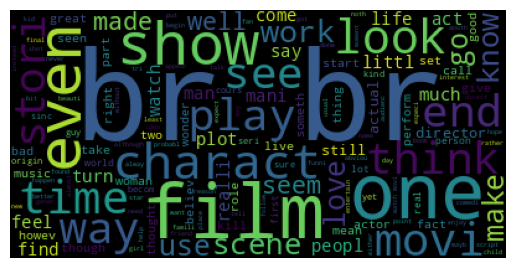

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import pandas as pd
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer
from sklearn.model_selection import train_test_split
import re

# Download necessary NLTK data (if not already downloaded)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)

# Re-define data and split if not already defined (for robustness)
if 'data' not in locals():
    data = pd.read_csv("IMDB Dataset.csv")
    stop_words = set(stopwords.words('english'))
    stemmer = PorterStemmer()
    lemmatizer = WordNetLemmatizer()

    def preprocess(text):
        text = text.lower()
        text = re.sub('[^a-zA-Z]', ' ', text)
        words = text.split()
        words = [w for w in words if w not in stop_words]
        words = [stemmer.stem(w) for w in words]
        words = [lemmatizer.lemmatize(w) for w in words]
        return " ".join(words)
    data['cleaned'] = data['review'].apply(preprocess)
    data['sentiment'] = data['sentiment'].map({'positive':1, 'negative':0})

if 'X_train' not in locals():
    X_train, X_test, y_train, y_test = train_test_split(
        data['cleaned'], data['sentiment'], test_size=0.2, random_state=42
    )

# Combine all cleaned training reviews into a single string
text = " ".join(X_train)

# Generate a word cloud from the combined text
wc = WordCloud().generate(text)

# Display the generated word cloud
plt.imshow(wc)
plt.axis('off') # Turn off axis labels
plt.show()

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer
import pandas as pd
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer
from sklearn.model_selection import train_test_split
import re

# Download necessary NLTK data (if not already downloaded)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)

# Re-define data and split if not already defined (for robustness)
if 'data' not in locals():
    data = pd.read_csv("IMDB Dataset.csv")
    stop_words = set(stopwords.words('english'))
    stemmer = PorterStemmer()
    lemmatizer = WordNetLemmatizer()

    def preprocess(text):
        text = text.lower()
        text = re.sub('[^a-zA-Z]', ' ', text)
        words = text.split()
        words = [w for w in words if w not in stop_words]
        words = [stemmer.stem(w) for w in words]
        words = [lemmatizer.lemmatize(w) for w in words]
        return " ".join(words)
    data['cleaned'] = data['review'].apply(preprocess)
    data['sentiment'] = data['sentiment'].map({'positive':1, 'negative':0})

if 'X_train' not in locals():
    X_train, X_test, y_train, y_test = train_test_split(
        data['cleaned'], data['sentiment'], test_size=0.2, random_state=42
    )

# Re-initialize and fit TF-IDF vectorizer if not already defined
if 'tfidf' not in locals():
    tfidf = TfidfVectorizer(max_features=5000)
    X_train_tfidf = tfidf.fit_transform(X_train)
    X_test_tfidf = tfidf.transform(X_test)
else:
    X_train_tfidf = tfidf.transform(X_train) # Ensure X_train_tfidf is up to date
    X_test_tfidf = tfidf.transform(X_test)

# Re-train Logistic Regression model with TF-IDF features if not already defined
if 'lr_tfidf' not in locals():
    lr_tfidf = LogisticRegression(max_iter=300)
    lr_tfidf.fit(X_train_tfidf, y_train)


# Get user input for a movie review
msg = input("Enter review: ")

# Preprocess the input message using the defined preprocess function
clean = preprocess(msg)
# Transform the cleaned message into a TF-IDF vector
vec = tfidf.transform([clean])

# Predict the sentiment using the trained Logistic Regression model (lr_tfidf)
pred = lr_tfidf.predict(vec)

# Print the predicted sentiment (Positive if 1, Negative if 0)
print("Positive" if pred[0]==1 else "Negative")

In [ ]:
class NaiveBayesScratch:
    def fit(self, X, y):
        self.classes = np.unique(y) # Get unique class labels
        self.mean = {} # Dictionary to store mean of features for each class
        self.var = {} # Dictionary to store variance of features for each class
        self.prior = {} # Dictionary to store prior probability of each class

        # Calculate mean, variance, and prior for each class
        for c in self.classes:
            X_c = X[y==c] # Filter data for the current class
            self.mean[c] = X_c.mean(axis=0) # Mean of features for class c
            self.var[c] = X_c.var(axis=0) # Variance of features for class c
            self.prior[c] = X_c.shape[0]/X.shape[0] # Prior probability of class c

    def predict(self, X):
        # Make predictions for each sample in X
        return [self._predict(x) for x in X]

    def _predict(self, x):
        post = [] # List to store posterior probabilities
        for c in self.classes:
            prior = np.log(self.prior[c]) # Log of prior probability
            # Calculate log-likelihood using Gaussian probability density function
            likelihood = np.sum(
                -0.5*np.log(2*np.pi*self.var[c]) -
                ((x-self.mean[c])**2)/(2*self.var[c])
            )
            post.append(prior+likelihood) # Add log-prior and log-likelihood
        return self.classes[np.argmax(post)] # Return the class with the maximum posterior probability

In [ ]:
class KNNScratch:
    def __init__(self, k=3):
        self.k = k # Initialize the number of neighbors (k)

    def fit(self, X, y):
        self.X = X # Store the training features
        self.y = y # Store the training labels

    def predict(self, X):
        preds = [] # List to store predictions
        for x in X:
            # Calculate Euclidean distance between the current test sample (x) and all training samples (self.X)
            dist = np.sqrt(np.sum((self.X-x)**2, axis=1))
            # Get the indices of the k nearest neighbors
            idx = np.argsort(dist)[:self.k]
            # Get the labels of the k nearest neighbors
            labels = self.y[idx]
            # Predict the class by finding the most frequent label among the k neighbors
            preds.append(np.bincount(labels).argmax())
        return preds

In [ ]:
# Convert sparse TF-IDF matrices to dense NumPy arrays for scratch implementations
X_train_arr = X_train_tfidf.toarray()
X_test_arr = X_test_tfidf.toarray()

# Initialize, fit, and predict with the Naive Bayes scratch model
nb = NaiveBayesScratch()
nb.fit(X_train_arr, y_train.values) # Fit the model with training data
print("NB Scratch:", accuracy_score(y_test, nb.predict(X_test_arr))) # Evaluate accuracy

# Initialize, fit, and predict with the KNN scratch model
knn = KNNScratch()
knn.fit(X_train_arr, y_train.values) # Fit the model with training data
print("KNN Scratch:", accuracy_score(y_test, knn.predict(X_test_arr))) # Evaluate accuracy

In [ ]:
# Summarize findings from the model evaluations
print("TF-IDF performed better than CountVectorizer")
print("Logistic Regression gave highest accuracy")
print("Scratch models worked but less accurate")